# Pronóstico de la TRM mensual frente a la caminata aleatoria

Tercera etapa del análisis de la Tasa Representativa del Mercado (TRM). En el notebook 02 se identificó un ARIMA(0,1,1) con constante para el promedio mensual de la TRM, cuya estructura de media móvil se explica por el efecto de agregación temporal (Working, 1960), y se incorporó un GARCH(1,1) con innovaciones t de Student para su varianza. A partir de esto, en este notebook se evalúa si ese modelo pronostica mejor que la caminata aleatoria, tanto en el valor puntual como en los intervalos, y se genera el pronóstico de los próximos 12 meses junto con la probabilidad de que la TRM supere determinados niveles, que es la información que resume el tablero del proyecto.

| Notebook | Etapa |
|---|---|
| 01 · Exploración de la serie diaria | Calidad, patrones periódicos, atípicos, estacionariedad y ACF/PACF |
| 02 · Modelado mensual | Identificación, estimación, diagnóstico y volatilidad (ARIMA + GARCH) |
| **03 · Pronóstico** | Evaluación frente a la caminata aleatoria y pronóstico a 12 meses |

**Fuente de datos:** Banco de la República (2026), Portal de Estadísticas Económicas. Serie diaria de la TRM.

---
## Preparación del entorno

In [1]:
# En Google Colab el paquete del proyecto se instala desde GitHub; en el entorno local ya queda disponible con uv sync
import importlib.util
from IPython import get_ipython

if importlib.util.find_spec("trm") is None:
    get_ipython().run_line_magic("pip", "install -q git+https://github.com/Juanhv24/Time-Series-Colombia.git")

In [2]:
import warnings

# Manejo de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt

# Paquete del proyecto
from trm import config, datos, evaluacion, modelo, pruebas
from trm.graficos import estilo, guardar, AZUL, ROJO, MORADO, GRIS

estilo()
# statsmodels registra sus propios filtros al importarse, por lo que los avisos se silencian después de las importaciones
warnings.filterwarnings("ignore")

### Serie y modelo final

La serie de trabajo y el modelo son los del notebook 02, es decir, el promedio mensual de los meses completos en la escala $X_t = 100\log(\overline{TRM}_t)$, con el ARIMA(0,1,1) con constante para la media y el GARCH(1,1)-t para la varianza, estimados mediante la función `modelo.ajustar_modelo` del paquete del proyecto.

In [3]:
serie = datos.cargar_trm()
X = datos.log_nivel(datos.serie_mensual(serie))
y = X.diff().dropna()

final = modelo.ajustar_modelo(X)
c, theta = final.media.params["intercept"], final.media.params["ma.L1"]
g = final.garch.params
print(f"Serie: {X.index.min():%Y-%m} a {X.index.max():%Y-%m} ({len(X)} meses)")
print(f"Media:    X_t = X_t-1 + {c:.4f} + e_t + {theta:.4f} e_t-1")
print(f"Varianza: s2_t = {g['omega']:.4f} + {g['alpha[1]']:.4f} e2_t-1 + {g['beta[1]']:.4f} s2_t-1 | grados de libertad = {g['nu']:.2f}")

Serie: 1991-12 a 2026-07 (416 meses)
Media:    X_t = X_t-1 + 0.3946 + e_t + 0.3277 e_t-1
Varianza: s2_t = 0.3084 + 0.1672 e2_t-1 + 0.8108 s2_t-1 | grados de libertad = 6.30


---
# 1. Esquema de evaluación

El esquema de evaluación compara tres pronósticos. El primero es la caminata aleatoria, que pronostica para cada mes el último valor observado y constituye la referencia habitual para las tasas de cambio, ya que los modelos estructurales no logran superarla fuera de la muestra (Meese & Rogoff, 1983). El segundo corresponde al ARIMA(0,1,1) con varianza constante y el tercero al modelo final, que conserva la misma ecuación para la media y reemplaza la varianza constante por el GARCH(1,1)-t, de modo que ambos modelos producen el mismo pronóstico puntual y su diferencia se encuentra en los intervalos.

En este caso se realizan dos ejercicios. Por un lado, un pronóstico estático a 12 meses, reservando el último año como conjunto de prueba, y por otro lado, dado que con 12 observaciones solo se esperan 0.6 casos por fuera de un intervalo del 95 %, se evalúan además 120 pronósticos a un paso, que permiten valorar la calibración de los intervalos (Christoffersen, 1998). Para finalizar, el error puntual se mide con MAE, RMSE y MAPE sobre la TRM en pesos por dólar (Hyndman & Koehler, 2006), y los intervalos del GARCH se obtienen como percentiles de 5000 trayectorias simuladas del modelo con una semilla fija, de modo que los resultados son reproducibles.

---
# 2. Pronóstico estático a 12 meses

In [4]:
estatico, modelo_train = evaluacion.pronostico_estatico(X, h=config.HORIZONTE)

print(f"Entrenamiento: {X.index[0]:%Y-%m} a {X.index[-config.HORIZONTE - 1]:%Y-%m} ({len(X) - config.HORIZONTE} meses)")
print(f"Prueba: {estatico.index[0]:%Y-%m} a {estatico.index[-1]:%Y-%m} ({len(estatico)} meses)")
print(f"Deriva estimada en entrenamiento: {modelo_train.media.params['intercept']:.4f} | theta: {modelo_train.media.params['ma.L1']:.4f}\n")

print(pd.DataFrame([
    {"Modelo": "Caminata aleatoria", **pruebas.metricas(estatico["real"], estatico["caminata"])},
    {"Modelo": "ARIMA(0,1,1)", **pruebas.metricas(estatico["real"], estatico["pronostico"])},
]).round(2).to_string(index=False))

dentro_cte = estatico["real"].between(estatico["inf_constante"], estatico["sup_constante"])
dentro_g = estatico["real"].between(estatico["inf_garch"], estatico["sup_garch"])
print(f"\nIntervalo del 95 % con varianza constante: cobertura {dentro_cte.mean():.1%}, "
      f"ancho medio {(estatico['sup_constante'] - estatico['inf_constante']).mean():.1f} COP")
print(f"Intervalo del 95 % con GARCH(1,1)-t: cobertura {dentro_g.mean():.1%}, "
      f"ancho medio {(estatico['sup_garch'] - estatico['inf_garch']).mean():.1f} COP")
print(f"Meses por fuera de ambos intervalos: {list(estatico.index[~dentro_cte & ~dentro_g].strftime('%Y-%m'))}")

print(f"\nTRM al cierre del entrenamiento: {estatico['caminata'].iloc[0]:.2f} | último mes de prueba: {estatico['real'].iloc[-1]:.2f}")
print(f"Volatilidad condicional al cierre del entrenamiento: {modelo_train.garch.conditional_volatility.iloc[-1]:.4f} "
      f"| desviación estándar del ARIMA: {np.sqrt(modelo_train.media.params['sigma2']):.4f}")

Entrenamiento: 1991-12 a 2025-07 (404 meses)
Prueba: 2025-08 a 2026-07 (12 meses)
Deriva estimada en entrenamiento: 0.4615 | theta: 0.3315

            Modelo    MAE   RMSE  MAPE (%)
Caminata aleatoria 323.38 375.62       9.0
      ARIMA(0,1,1) 424.05 493.06      11.8

Intervalo del 95 % con varianza constante: cobertura 91.7%, ancho medio 1388.8 COP
Intervalo del 95 % con GARCH(1,1)-t: cobertura 91.7%, ancho medio 1328.7 COP
Meses por fuera de ambos intervalos: ['2026-07']

TRM al cierre del entrenamiento: 4040.85 | último mes de prueba: 3268.95
Volatilidad condicional al cierre del entrenamiento: 2.6142 | desviación estándar del ARIMA: 2.7258


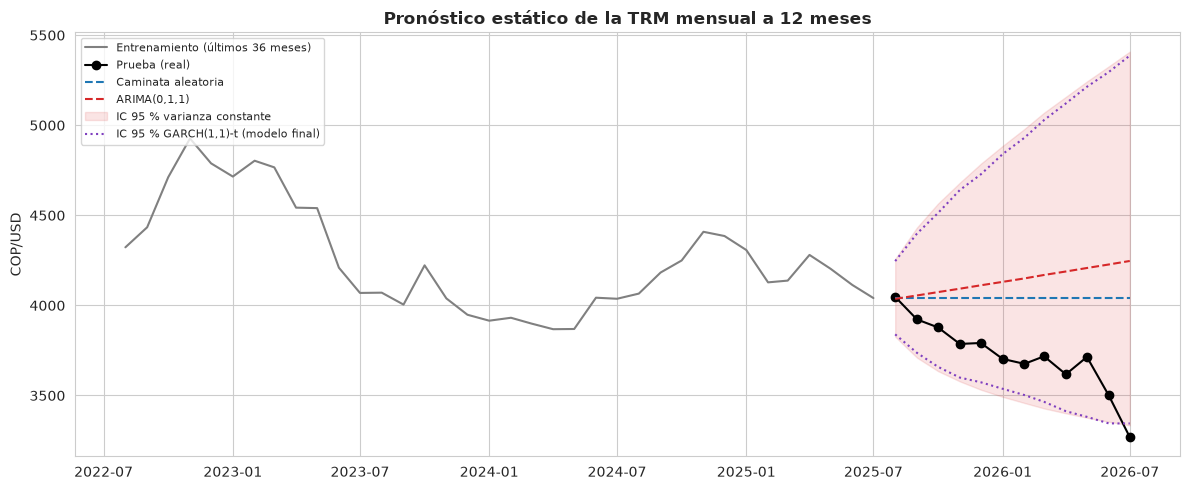

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
historia = datos.a_pesos(X.iloc[-config.HORIZONTE - 36:-config.HORIZONTE])
ax.plot(historia.index, historia.values, color="gray", label="Entrenamiento (últimos 36 meses)")
ax.plot(estatico.index, estatico["real"], color="black", marker="o", label="Prueba (real)")
ax.plot(estatico.index, estatico["caminata"], "--", color=AZUL, label="Caminata aleatoria")
ax.plot(estatico.index, estatico["pronostico"], "--", color=ROJO, label="ARIMA(0,1,1)")
ax.fill_between(estatico.index, estatico["inf_constante"], estatico["sup_constante"], color=ROJO, alpha=0.12,
                label="IC 95 % varianza constante")
ax.plot(estatico.index, estatico["inf_garch"], ":", color=MORADO, label="IC 95 % GARCH(1,1)-t (modelo final)")
ax.plot(estatico.index, estatico["sup_garch"], ":", color=MORADO)
ax.set_title("Pronóstico estático de la TRM mensual a 12 meses")
ax.set_ylabel("COP/USD")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
guardar(fig, "14_pronostico_prueba.png")
plt.show()

**Interpretación:** A partir de los resultados se observa que en el conjunto de prueba, comprendido entre agosto de 2025 y julio de 2026, la caminata aleatoria obtiene menores errores que el ARIMA(0,1,1) en las tres métricas, con un MAE de 323.38 frente a 424.05 pesos y un MAPE de 9.0 % frente a 11.8 %. Esto se explica porque la TRM pasó de 4040.85 al cierre del entrenamiento a 3268.95 en el último mes de prueba, mientras que el ARIMA proyecta la deriva de 0.4615 estimada en el entrenamiento, es decir, una depreciación mensual que no ocurrió en ese año. Con lo que respecta a los intervalos, ambos cubren 11 de los 12 meses, con una cobertura de 91.7 %, y el del GARCH resulta ligeramente más angosto, con un ancho medio de 1328.7 frente a 1388.8 pesos, debido a que al cierre del entrenamiento la volatilidad condicional, de 2.6142, era inferior a la desviación estándar de 2.7258 que supone el ARIMA. Finalmente, en la gráfica se observa que el único mes por fuera de ambos intervalos es julio de 2026, en el que la TRM cae por debajo del límite inferior.

---
# 3. Pronóstico a un paso sobre los últimos 120 meses

Los parámetros se estiman con datos hasta julio de 2016 y se mantienen fijos, de modo que cada pronóstico utiliza únicamente la información disponible hasta el mes anterior. Además, para comparar la precisión de los dos pronósticos puntuales se aplica la prueba de Diebold y Mariano (1995), cuya hipótesis nula es que ambos tienen la misma precisión.

In [6]:
un_paso, info = evaluacion.pronostico_un_paso(X, H=config.VENTANA_UN_PASO)
real_1, arima_1, rw_1 = (datos.a_pesos(un_paso[col]) for col in ["real", "arima", "caminata"])

print(f"Ventana de evaluación: {un_paso.index[0]:%Y-%m} a {un_paso.index[-1]:%Y-%m} ({len(un_paso)} pronósticos a un paso)")
print(f"Parámetros estimados hasta {info['fin_estimacion']:%Y-%m} -> theta = {info['theta']:.4f} | deriva = {info['deriva']:.4f}\n")
print(pd.DataFrame([
    {"Modelo": "Caminata aleatoria", **pruebas.metricas(real_1, rw_1)},
    {"Modelo": "ARIMA(0,1,1)", **pruebas.metricas(real_1, arima_1)},
]).round(2).to_string(index=False))

print("\n" + evaluacion.calibracion(un_paso, info).to_string(index=False))

Ventana de evaluación: 2016-08 a 2026-07 (120 pronósticos a un paso)
Parámetros estimados hasta 2016-07 -> theta = 0.4603 | deriva = 0.5260

            Modelo   MAE   RMSE  MAPE (%)
Caminata aleatoria 87.33 118.72      2.34
      ARIMA(0,1,1) 94.42 128.85      2.52

Nivel Esperado fuera Fuera var. constante Fuera GARCH-t  Ancho var. constante  Ancho GARCH-t
  95%           5.0%                11.7%          6.7%                 362.6          471.5
  99%           1.0%                 5.0%          1.7%                 476.6          705.0


In [7]:
e_arima, e_rw = real_1 - arima_1, real_1 - rw_1
for nombre, perdida in [("absoluta", np.abs), ("cuadrática", np.square)]:
    dm, p_dm = pruebas.diebold_mariano(e_arima, e_rw, perdida)
    print(f"Diebold-Mariano, pérdida {nombre}: DM = {dm:.3f} | p-valor = {p_dm:.4f}")

Diebold-Mariano, pérdida absoluta: DM = 1.409 | p-valor = 0.1588
Diebold-Mariano, pérdida cuadrática: DM = 1.470 | p-valor = 0.1417


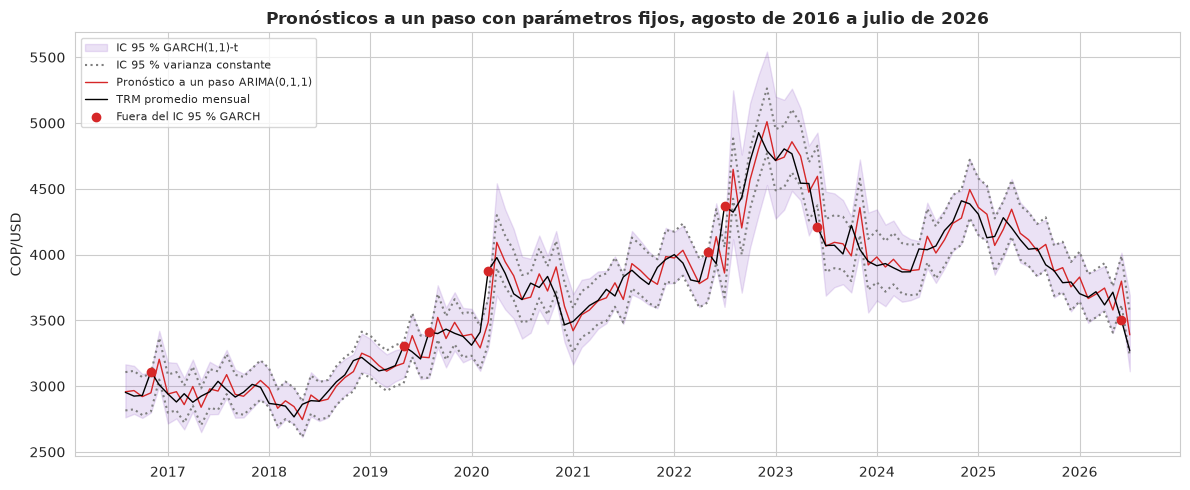

Meses por fuera del IC 95 % GARCH: 8 de 120


In [8]:
limites = evaluacion.limites_un_paso(un_paso, info)
fuera_g = ~real_1.between(limites["inf_garch"], limites["sup_garch"])

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(limites.index, limites["inf_garch"], limites["sup_garch"], color=MORADO, alpha=0.15,
                label="IC 95 % GARCH(1,1)-t")
ax.plot(limites.index, limites["inf_constante"], ":", color=GRIS, label="IC 95 % varianza constante")
ax.plot(limites.index, limites["sup_constante"], ":", color=GRIS)
ax.plot(arima_1.index, arima_1.values, color=ROJO, linewidth=1, label="Pronóstico a un paso ARIMA(0,1,1)")
ax.plot(real_1.index, real_1.values, color="black", linewidth=1, label="TRM promedio mensual")
ax.scatter(real_1.index[fuera_g], real_1[fuera_g], color=ROJO, zorder=3, label="Fuera del IC 95 % GARCH")
ax.set_title("Pronósticos a un paso con parámetros fijos, agosto de 2016 a julio de 2026")
ax.set_ylabel("COP/USD")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
guardar(fig, "15_pronostico_un_paso.png")
plt.show()
print(f"Meses por fuera del IC 95 % GARCH: {fuera_g.sum()} de {len(fuera_g)}")

**Interpretación:** Al evaluar 120 pronósticos a un paso, entre agosto de 2016 y julio de 2026, la caminata aleatoria vuelve a presentar menores errores, con un MAE de 87.33 frente a 94.42 pesos y un RMSE de 118.72 frente a 128.85. A pesar de esto, la prueba de Diebold-Mariano no rechaza la igualdad de precisión, con p-valores de 0.1588 para la pérdida absoluta y de 0.1417 para la cuadrática, lo que quiere decir que no es posible afirmar que alguno de los dos pronósticos sea más preciso que el otro.

Por otro lado, es en los intervalos donde el modelo final marca la diferencia, ya que con varianza constante el 11.7 % de las observaciones queda por fuera del intervalo del 95 %, más del doble del 5.0 % esperado, mientras que con el GARCH(1,1)-t esta proporción es de 6.7 %. Además, al 99 % el contraste es similar, con 5.0 % frente a 1.7 % cuando se esperaba 1.0 %. Esta mejora se obtiene con intervalos más anchos en promedio, de 471.5 frente a 362.6 pesos al 95 %, por lo que el GARCH no reduce la incertidumbre, sino que la representa de forma más fiel, ampliando el intervalo en los períodos de mayor volatilidad, como se observa en la gráfica durante 2020 y 2022.

---
# 4. Estabilidad de la estructura de media móvil

Para explicar por qué el ARIMA(0,1,1) no supera a la caminata aleatoria, se compara la autocorrelación de primer orden del log-retorno en el período utilizado para estimar los parámetros y en el período de evaluación.

In [9]:
print(evaluacion.estabilidad_acf(y, [("1992-01", "2016-07"), ("2016-08", "2026-07")]).to_string(index=False))

            Tramo   n  ACF(1)  Umbral
1992-01 a 2016-07 295  0.4144 ±0.1141
2016-08 a 2026-07 120  0.0906 ±0.1789


**Interpretación:** La autocorrelación de primer orden pasa de 0.4144 entre enero de 1992 y julio de 2016 a 0.0906 entre agosto de 2016 y julio de 2026, valor que ya no supera el umbral de ±0.1789 de ese tramo. Teniendo en cuenta lo anterior, el modelo estimado con los datos hasta 2016, con un coeficiente de media móvil de 0.4603, trasladó al período de evaluación una dependencia que en él se debilitó, lo que explica que sus pronósticos no superen a los de la caminata aleatoria. Este resultado es consistente con la literatura sobre tasas de cambio, en la que la capacidad predictiva de los modelos resulta inestable en el tiempo (Rossi, 2013), y constituye un matiz sobre la conclusión del notebook 02, ya que la estructura MA(1) existe en la muestra completa pero no se mantiene con la misma intensidad en la última década. Finalmente, cabe resaltar que la distancia entre 0.0906 y el 0.25 que predice la agregación temporal (Working, 1960) es inferior al umbral de ese tramo, por lo que con 120 observaciones los datos no permiten distinguir con precisión entre ese valor y la ausencia de autocorrelación.

---
# 5. Pronóstico de los próximos 12 meses

Con el modelo final estimado sobre toda la serie se genera el pronóstico entre agosto de 2026 y julio de 2027. Además de los intervalos del 95 % bajo varianza constante y bajo el GARCH(1,1)-t, la gráfica presenta las bandas del 50 % y del 80 % obtenidas de las mismas trayectorias simuladas, con el fin de mostrar cómo se distribuye la incertidumbre dentro del intervalo.

In [10]:
pronostico = final.pronostico(pasos=config.HORIZONTE)
tabla_futuro = pronostico[["pronostico", "inf_garch", "sup_garch"]].copy()
tabla_futuro["ancho GARCH-t"] = pronostico["sup_garch"] - pronostico["inf_garch"]
tabla_futuro["ancho var. constante"] = pronostico["sup_constante"] - pronostico["inf_constante"]
tabla_futuro.index = tabla_futuro.index.strftime("%Y-%m")
print(tabla_futuro.round(2).to_string())

print(f"\nResiduo del último mes observado: {final.residuos.iloc[-1]:.4f}")
print(f"Volatilidad condicional del último mes observado: {final.garch.conditional_volatility.iloc[-1]:.4f} "
      f"| desviación estándar constante del ARIMA: {np.sqrt(final.media.params['sigma2']):.4f}")

         pronostico  inf_garch  sup_garch  ancho GARCH-t  ancho var. constante
2026-08     3230.37    2979.42    3505.15         525.73                347.73
2026-09     3243.14    2843.68    3693.83         850.15                580.76
2026-10     3255.96    2744.79    3831.42        1086.63                746.87
2026-11     3268.83    2666.81    3986.21        1319.40                884.62
2026-12     3281.76    2624.07    4086.80        1462.73               1005.78
2027-01     3294.73    2583.53    4220.29        1636.76               1115.77
2027-02     3307.76    2545.46    4324.57        1779.11               1217.67
2027-03     3320.84    2498.59    4455.98        1957.39               1313.38
2027-04     3333.97    2430.28    4556.07        2125.79               1404.18
2027-05     3347.15    2386.84    4646.67        2259.83               1491.00
2027-06     3360.38    2351.62    4763.59        2411.97               1574.51
2027-07     3373.67    2337.51    4848.29        251

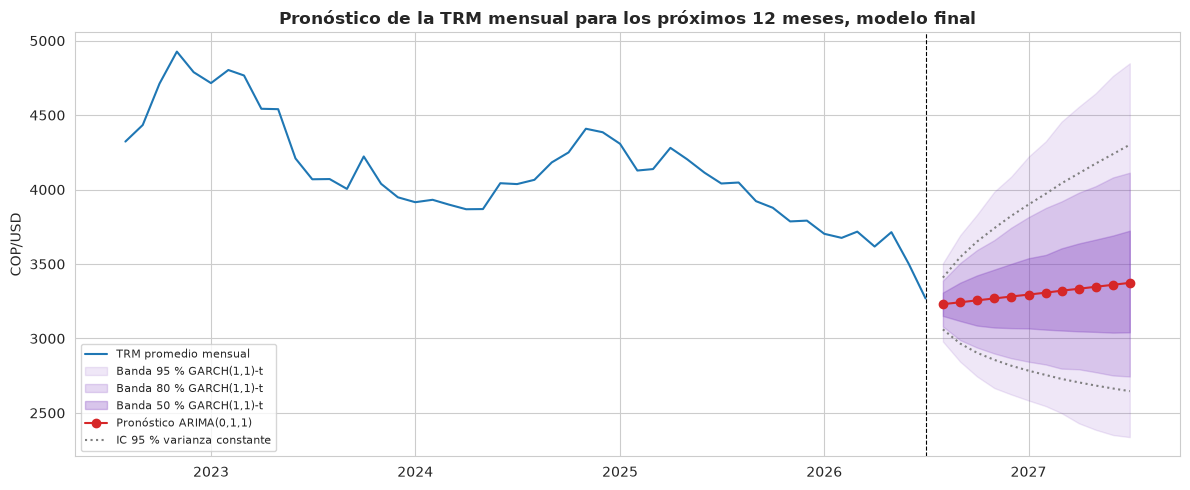

In [11]:
trayectorias = final.trayectorias(pasos=config.HORIZONTE)
bandas = {nivel: np.exp(np.percentile(trayectorias, [50 - nivel / 2, 50 + nivel / 2], axis=0) / 100)
          for nivel in (50, 80, 95)}

fig, ax = plt.subplots(figsize=(12, 5))
historia = datos.a_pesos(X.iloc[-48:])
ax.plot(historia.index, historia.values, color=AZUL, label="TRM promedio mensual")
for nivel, alfa in [(95, 0.12), (80, 0.2), (50, 0.3)]:
    ax.fill_between(pronostico.index, *bandas[nivel], color=MORADO, alpha=alfa, label=f"Banda {nivel} % GARCH(1,1)-t")
ax.plot(pronostico.index, pronostico["pronostico"], color=ROJO, marker="o", label="Pronóstico ARIMA(0,1,1)")
ax.plot(pronostico.index, pronostico["inf_constante"], ":", color=GRIS, label="IC 95 % varianza constante")
ax.plot(pronostico.index, pronostico["sup_constante"], ":", color=GRIS)
ax.axvline(X.index[-1], color="black", linestyle="--", linewidth=0.8)
ax.set_title("Pronóstico de la TRM mensual para los próximos 12 meses, modelo final")
ax.set_ylabel("COP/USD")
ax.legend(loc="lower left", fontsize=8)
plt.tight_layout()
guardar(fig, "16_pronostico_futuro.png")
plt.show()

**Interpretación:** El pronóstico parte de 3230.37 pesos por dólar en agosto de 2026, valor inferior a la TRM de 3268.95 de julio de 2026, debido a que el término de media móvil incorpora parte del residuo negativo de -4.8274 del último mes. A partir del segundo mes el pronóstico aumenta de forma gradual hasta 3373.67 en julio de 2027, siguiendo únicamente la deriva de 0.3946, ya que en un MA(1) el término de media móvil deja de aportar información más allá del primer paso (Box et al., 2015). Por otro lado, los intervalos del GARCH(1,1)-t son más amplios que los obtenidos con varianza constante en todo el horizonte, con un ancho de 525.73 frente a 347.73 pesos en el primer mes, lo cual se explica porque la volatilidad condicional del último mes observado es de 3.9030, superior a la desviación estándar de 2.7447 que supone el ARIMA. Teniendo en cuenta lo evaluado en la sección 3, el intervalo del modelo final es la representación más fiel de la incertidumbre del pronóstico, mientras que el valor puntual debe leerse con la cautela que imponen los resultados frente a la caminata aleatoria.

---
# 6. Del pronóstico a una decisión: probabilidad de superar un umbral

Teniendo en cuenta que el aporte del modelo final se encuentra en la varianza y no en el pronóstico puntual, la forma más útil de comunicar el pronóstico no es un único valor, sino la probabilidad de que la TRM se ubique por encima o por debajo de un nivel relevante para una decisión, como la tasa con la que un importador elaboró su presupuesto o la que un exportador necesita para cubrir sus costos. Dado que las 5000 trayectorias simuladas representan la distribución del pronóstico bajo el modelo final, esta probabilidad se estima como la proporción de trayectorias en las que el promedio mensual de la TRM supera el umbral en cada horizonte.

Probabilidad (%) de que el promedio mensual de la TRM supere cada umbral
         > 3000  > 3250  > 3500  > 3750  > 4000
2026-08    96.7    44.0     2.6     0.2     0.1
2026-10    84.9    50.4    16.6     4.2     1.2
2027-01    80.8    54.3    28.3    12.7     5.3
2027-07    77.4    59.9    40.0    23.6    13.5


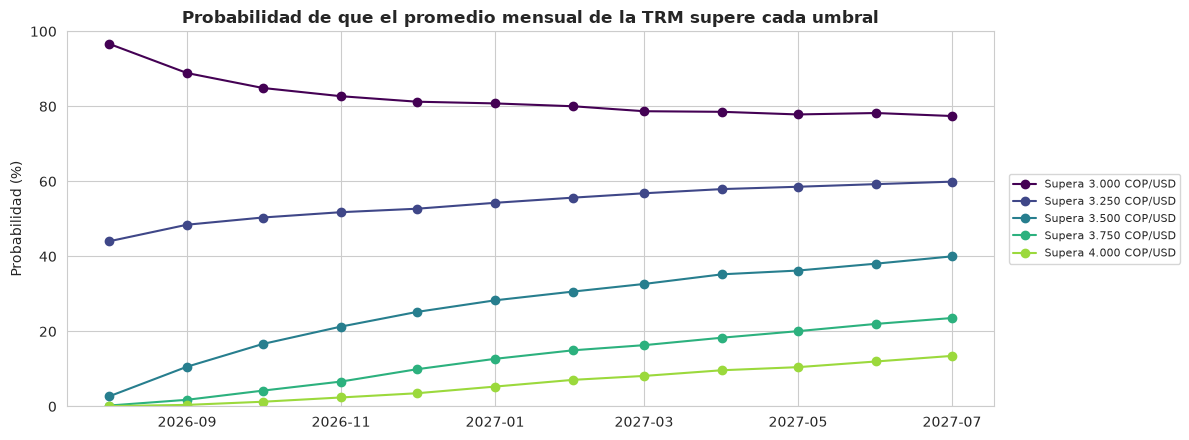

In [12]:
umbrales = [3000, 3250, 3500, 3750, 4000]
probabilidades = pd.DataFrame(
    {f"> {u}": modelo.probabilidad_superar(trayectorias, u) * 100 for u in umbrales},
    index=pronostico.index.strftime("%Y-%m"),
)
print("Probabilidad (%) de que el promedio mensual de la TRM supere cada umbral")
print(probabilidades.iloc[[0, 2, 5, 11]].round(1).to_string())

fig, ax = plt.subplots(figsize=(12, 4.5))
for u, color in zip(umbrales, plt.cm.viridis(np.linspace(0, 0.85, len(umbrales)))):
    ax.plot(pronostico.index, probabilidades[f"> {u}"], marker="o", color=color, label=f"Supera {u:,} COP/USD".replace(",", "."))
ax.set_title("Probabilidad de que el promedio mensual de la TRM supere cada umbral")
ax.set_ylabel("Probabilidad (%)")
ax.set_ylim(0, 100)
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=8)
plt.tight_layout()
guardar(fig, "17_probabilidad_umbral.png")
plt.show()

**Interpretación:** A partir de la tabla podemos observar que la probabilidad de superar un umbral cercano al nivel actual, como 3250 pesos, se ubica entre 44.0 % y 59.9 % a lo largo del horizonte, lo cual es coherente con un pronóstico puntual que parte levemente por debajo del último valor observado y luego crece con la deriva. Por otro lado, la probabilidad de los umbrales alejados del nivel actual aumenta con el horizonte, ya que superar 3500 pesos pasa de 2.6 % en agosto de 2026 a 28.3 % en enero de 2027 y a 40.0 % en julio de 2027, mientras que la probabilidad de que la TRM se ubique por debajo de 3000 pesos pasa de 3.3 % a 22.6 % en el mismo período. Además, un nivel como 4000 pesos, que el promedio mensual superó por última vez en agosto de 2025, alcanza una probabilidad de 13.5 % a 12 meses, lo que ilustra el peso de las colas de la distribución t y de la volatilidad condicional elevada con la que termina la serie.

Teniendo en cuenta lo anterior, para un importador que presupuestó con una TRM de 3500 pesos el riesgo de que el promedio mensual supere ese nivel es bajo en los próximos meses, pero se aproxima a 2 de cada 5 escenarios al cabo de un año, información que un valor puntual de 3373.67 pesos no transmite. Finalmente, cabe resaltar que estas probabilidades dependen de los supuestos del modelo, por lo que deben leerse como una medida de riesgo y no como una predicción del valor que tomará la tasa de cambio.

---
# 7. Dificultades observadas durante la etapa

En primer lugar, en la etapa de predicción se evidenció que un buen ajuste dentro de la muestra no garantiza una mejora en el pronóstico, ya que la autocorrelación de primer orden se debilitó en la última década, por lo que el ARIMA(0,1,1) no logró superar a la caminata aleatoria. A esto se suma que el año de prueba correspondió a un período de apreciación del peso, en el que la deriva estimada con la historia de la serie jugó en contra del pronóstico.

Por otro lado, la evaluación de los intervalos presentó dos limitaciones. La primera es que 12 meses de prueba resultan insuficientes para juzgar la cobertura de un intervalo del 95 %, lo que obligó a complementar con 120 pronósticos a un paso, y la segunda es que esa calibración se verificó a un paso, mientras que las probabilidades de la sección 6 abarcan horizontes de hasta 12 meses, en los que la acumulación de choques depende de que la persistencia estimada del GARCH se mantenga. Finalmente, al estimarse el GARCH en dos etapas, la incertidumbre de la estimación de la media no se incorpora en las trayectorias simuladas, por lo que los intervalos pueden resultar algo más angostos de lo que corresponde.

---
# 8. Conclusiones del proyecto

| Etapa | Resultado |
|---|---|
| **Exploración** (notebook 01) | TRM integrada de orden 1, con colas pesadas, agrupamiento de volatilidad y un patrón semanal que es un artefacto de la regla de publicación |
| **Identificación** (notebook 02) | Log-nivel integrado de orden 1 y sin estacionalidad; un único coeficiente significativo en el primer rezago, compatible con la hipótesis de agregación temporal |
| **Estimación** (notebook 02) | ARIMA(0,1,1) con constante, con el menor BIC de la grilla. Términos estacionales no significativos en conjunto (p-valor de 0.0760) |
| **Diagnóstico** (notebook 02) | Residuos sin autocorrelación según Ljung-Box, pero con efectos ARCH (p-valor de 0.0032), capturados por un GARCH(1,1) con innovaciones t |
| **Predicción** (notebook 03) | Sin diferencia significativa frente a la caminata aleatoria en el pronóstico puntual; intervalos mejor calibrados con el GARCH (6.7 % frente a 11.7 % por fuera al 95 %) |

El modelo final de la TRM queda compuesto por

$$X_t = X_{t-1} + 0.3946 + \varepsilon_t + 0.3277\, \varepsilon_{t-1}, \qquad \varepsilon_t = \sigma_t z_t, \qquad \sigma_t^2 = 0.3084 + 0.1672\, \varepsilon_{t-1}^2 + 0.8108\, \sigma_{t-1}^2$$

con $z_t$ distribuida como una t de Student estandarizada de 6.30 grados de libertad. Teniendo en cuenta los resultados, es posible concluir que la estructura de media móvil identificada se mantiene en la totalidad de la muestra, sin embargo, su intensidad se reduce en la última década, lo cual limita su utilidad para el pronóstico puntual y es consistente con la dificultad documentada para superar a la caminata aleatoria en tasas de cambio (Meese & Rogoff, 1983; Rossi, 2013). A pesar de esto, el aporte principal del modelo final se encuentra en la varianza, ya que el GARCH(1,1) representa de forma más fiel la incertidumbre del pronóstico, lo que resulta relevante para cualquier uso de la TRM que dependa de la magnitud de los movimientos extremos y no solo de su valor esperado. Por esta razón, el tablero del proyecto presenta el pronóstico como bandas de riesgo y probabilidades de superar un umbral, y no como un valor puntual.

---
# Referencias

Banco de la República. (2026). *Tasa Representativa del Mercado (TRM). Serie diaria 1991-2026* [Conjunto de datos]. Portal de Estadísticas Económicas. https://suameca.banrep.gov.co/estadisticas-economicas/

Box, G. E. P., Jenkins, G. M., Reinsel, G. C., & Ljung, G. M. (2015). *Time series analysis: Forecasting and control* (5.ª ed.). Wiley.

Christoffersen, P. F. (1998). Evaluating interval forecasts. *International Economic Review, 39*(4), 841–862.

Diebold, F. X., & Mariano, R. S. (1995). Comparing predictive accuracy. *Journal of Business & Economic Statistics, 13*(3), 253–263.

Hyndman, R. J., & Koehler, A. B. (2006). Another look at measures of forecast accuracy. *International Journal of Forecasting, 22*(4), 679–688.

Meese, R. A., & Rogoff, K. (1983). Empirical exchange rate models of the seventies: Do they fit out of sample? *Journal of International Economics, 14*(1–2), 3–24.

Rossi, B. (2013). Exchange rate predictability. *Journal of Economic Literature, 51*(4), 1063–1119.

Working, H. (1960). Note on the correlation of first differences of averages in a random chain. *Econometrica, 28*(4), 916–918.